# 01 — Data Acquisition\n\nDownloading Sentinel-2 composites + ESA WorldCover 2021 labels from GEE.\n\n- Source: Iowa, Jul-Aug 2021\n- Target: Niamey (Niger), Oct-Nov 2021\n- 256x256 chips @ 10m, 5 bands (B2/B3/B4/B8/NDVI), 7 classes\n\nWorldCover is ~75% accurate and worse in the Sahel, so some target "errors" later might just be noisy labels.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from src.data_acquisition import (
    initialize_gee, download_domain, create_splits,
    load_chip, compute_dataset_stats,
    SOURCE_AOI, TARGET_AOI, CLASS_NAMES, NUM_CLASSES,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
initialize_gee()
print("GEE initialized")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


GEE initialized


## Download source domain (Iowa)

In [2]:
source_stats = download_domain(SOURCE_AOI, Path("../data/source"), max_workers=10)
print(source_stats)

INFO: source: 399 potential chips in grid, sampling 300



INFO: source: {'total': 300, 'success': 300, 'failed': 0, 'failed_indices': []}


{'total': 300, 'success': 300, 'failed': 0, 'failed_indices': []}


## Download target domain (Niger / Sahel)

In [3]:
target_stats = download_domain(TARGET_AOI, Path("../data/target"), max_workers=10)
print(target_stats)

INFO: target: 336 potential chips in grid, sampling 300



INFO: target: {'total': 300, 'success': 300, 'failed': 0, 'failed_indices': []}


{'total': 300, 'success': 300, 'failed': 0, 'failed_indices': []}


## Create train/val splits\n\n- Source: 85% train / 15% val (for model selection)\n- Target: 240 train (unlabeled for UDA) / 60 eval (labels for evaluation only)

In [4]:
splits = create_splits(Path("../data/source"), Path("../data/target"))
print(f"Source — train: {len(splits['source']['train'])}, val: {len(splits['source']['val'])}")
print(f"Target — train: {len(splits['target']['train'])}, eval: {len(splits['target']['eval'])}")

Source — train: 255, val: 45
Target — train: 240, eval: 60


## Sanity check — RGB + labels for 5 source and 5 target chips

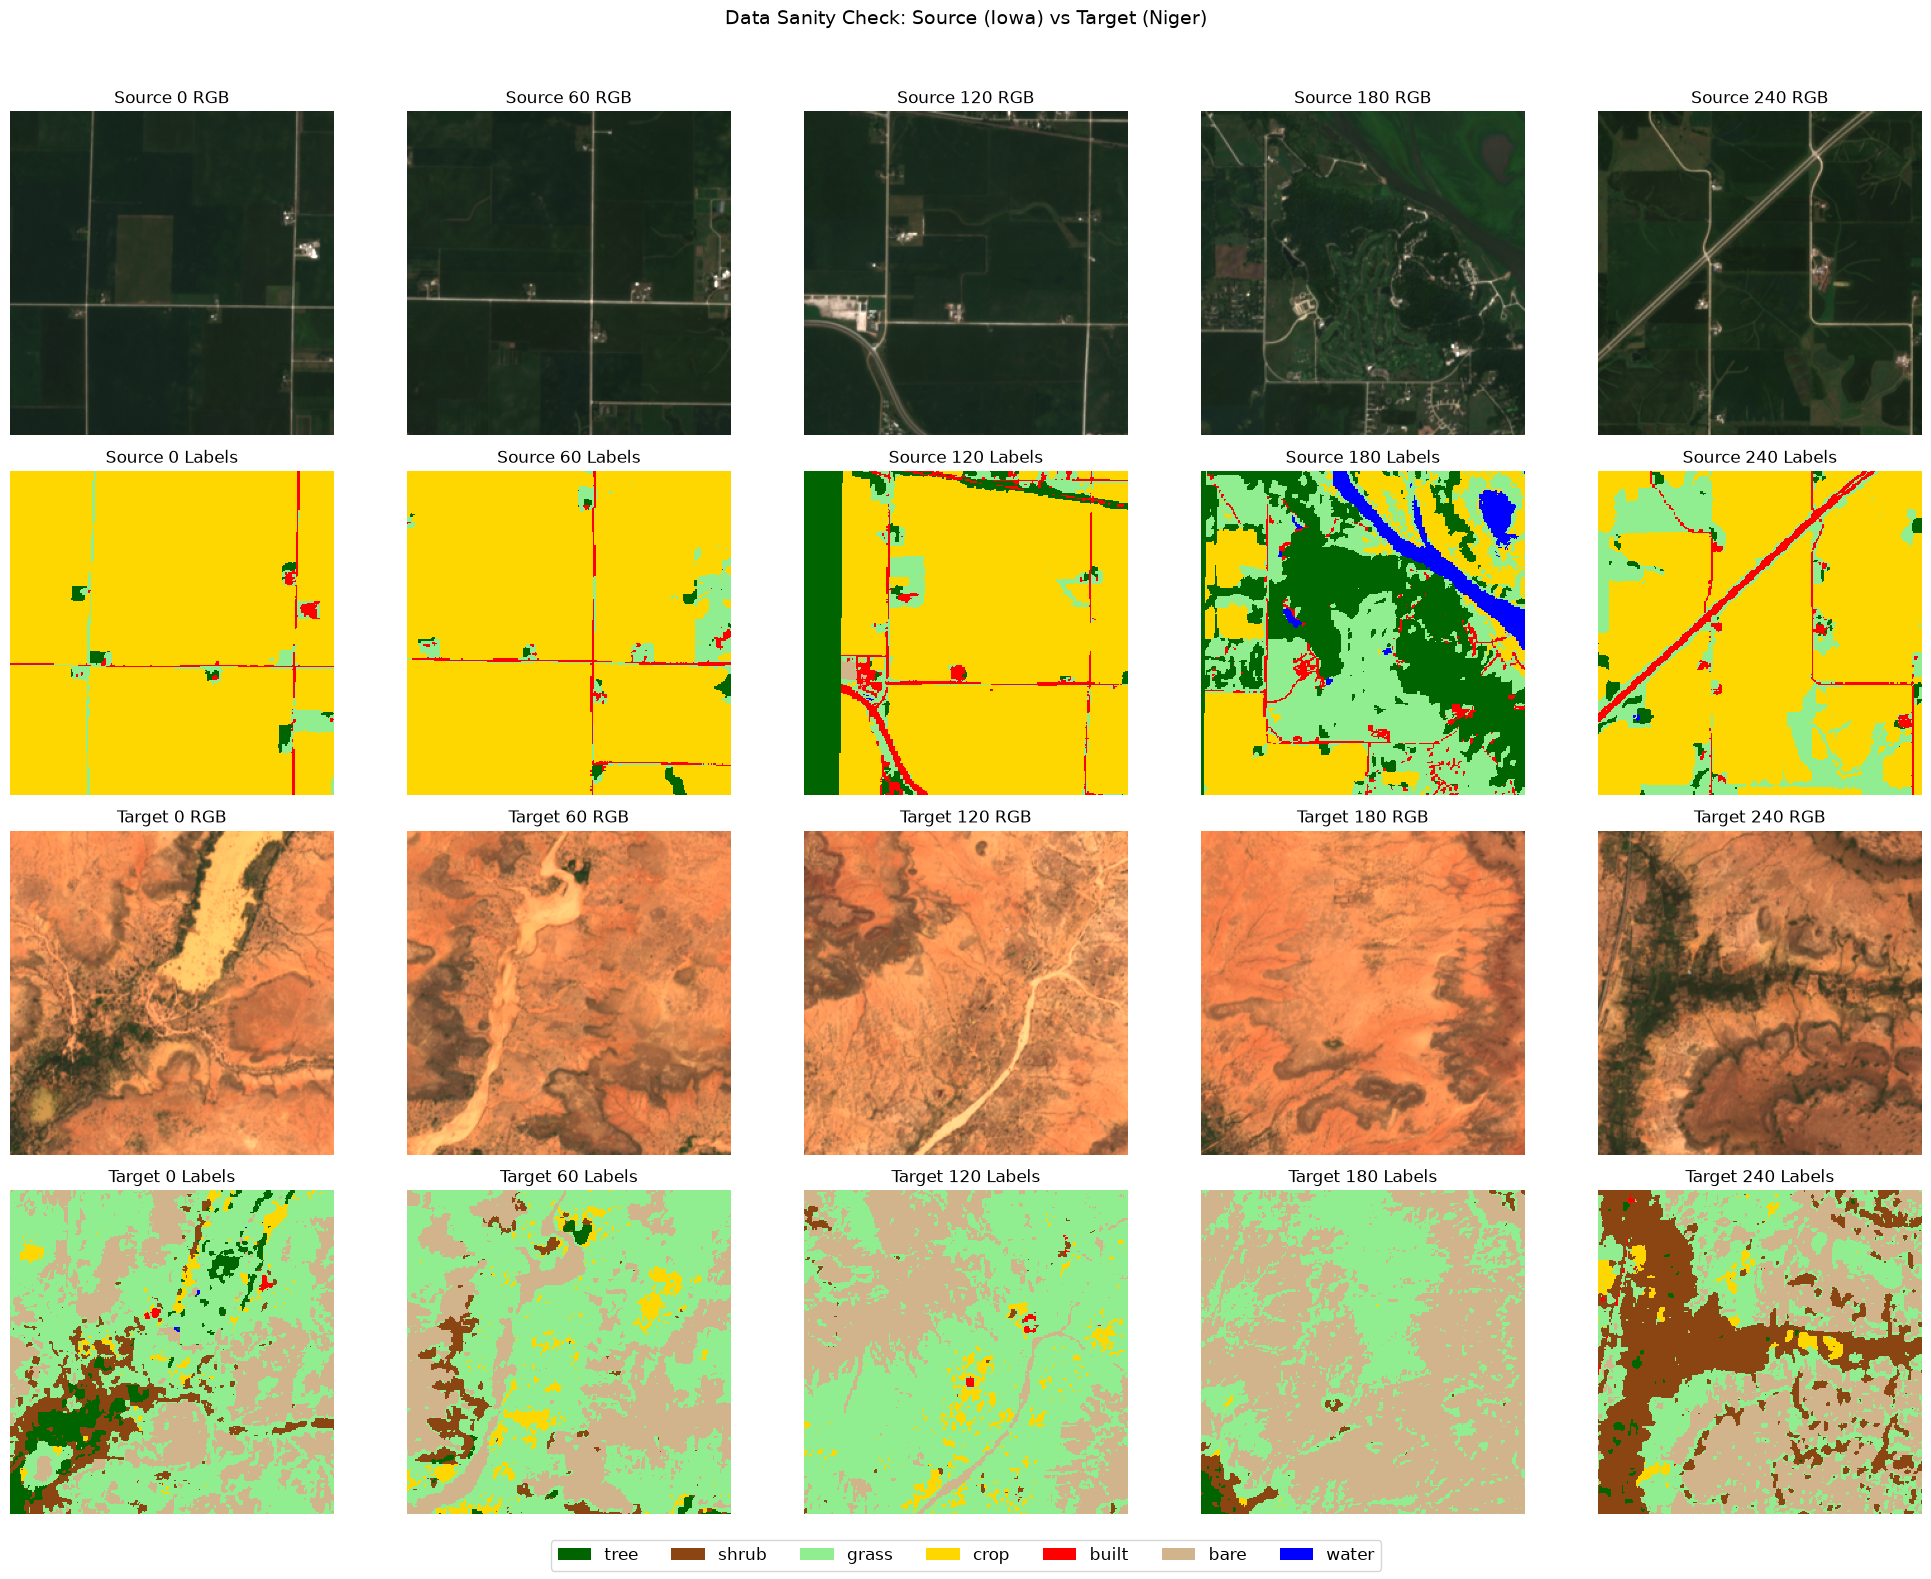

In [5]:
CLASS_COLORS = ["#006400", "#8B4513", "#90EE90", "#FFD700", "#FF0000", "#D2B48C", "#0000FF"]
cmap = mcolors.ListedColormap(CLASS_COLORS)
norm = mcolors.BoundaryNorm(np.arange(NUM_CLASSES + 1) - 0.5, NUM_CLASSES)

source_dir = Path("../data/source")
target_dir = Path("../data/target")

# Pick 5 evenly spaced chips from each domain
source_chips = sorted(int(p.stem.split("_")[1]) for p in (source_dir / "images").glob("chip_*.npy"))
target_chips = sorted(int(p.stem.split("_")[1]) for p in (target_dir / "images").glob("chip_*.npy"))
src_show = [source_chips[i * len(source_chips) // 5] for i in range(5)]
tgt_show = [target_chips[i * len(target_chips) // 5] for i in range(5)]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for col, idx in enumerate(src_show):
    img, lbl = load_chip(source_dir, idx)
    rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) * 3, 0, 1)
    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"Source {idx} RGB")
    axes[1, col].imshow(lbl, cmap=cmap, norm=norm, interpolation="nearest")
    axes[1, col].set_title(f"Source {idx} Labels")

for col, idx in enumerate(tgt_show):
    img, lbl = load_chip(target_dir, idx)
    rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) * 3, 0, 1)
    axes[2, col].imshow(rgb)
    axes[2, col].set_title(f"Target {idx} RGB")
    axes[3, col].imshow(lbl, cmap=cmap, norm=norm, interpolation="nearest")
    axes[3, col].set_title(f"Target {idx} Labels")

for ax in axes.flat:
    ax.axis("off")

# Legend
patches = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in CLASS_COLORS]
fig.legend(patches, CLASS_NAMES, loc="lower center", ncol=7, fontsize=12)
fig.suptitle("Data Sanity Check: Source (Iowa) vs Target (Niger)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("../report/figures/01_data_sanity.png", dpi=150, bbox_inches="tight")
plt.show()

## Dataset statistics\n\nNormalization stats computed on **source train split only** (no target leakage).

In [6]:
with open(source_dir / "splits.json") as f:
    src_splits = json.load(f)
with open(target_dir / "splits.json") as f:
    tgt_splits = json.load(f)

# Compute stats on source train only
src_stats = compute_dataset_stats(source_dir, src_splits["train"])
tgt_stats = compute_dataset_stats(target_dir, list(range(len(target_chips))))

band_names = ["B2", "B3", "B4", "B8", "NDVI"]
print("Source train per-band statistics:")
for i, name in enumerate(band_names):
    print(f"  {name}: mean={src_stats['mean'][i]:.4f}, std={src_stats['std'][i]:.4f}")

print(f"\nSource train chips: {src_stats['n_chips']}")
print(f"Target chips: {tgt_stats['n_chips']}")

# Save source stats for normalization in later phases
stats_path = source_dir / "norm_stats.json"
with open(stats_path, "w") as f:
    json.dump({"mean": src_stats["mean"], "std": src_stats["std"]}, f, indent=2)
print(f"\nNormalization stats saved to {stats_path}")

Source train per-band statistics:
  B2: mean=0.0431, std=0.0230
  B3: mean=0.0625, std=0.0255
  B4: mean=0.0453, std=0.0321
  B8: mean=0.3951, std=0.0874
  NDVI: mean=0.7830, std=0.1552

Source train chips: 255
Target chips: 300

Normalization stats saved to ../data/source/norm_stats.json


## Class distribution comparison

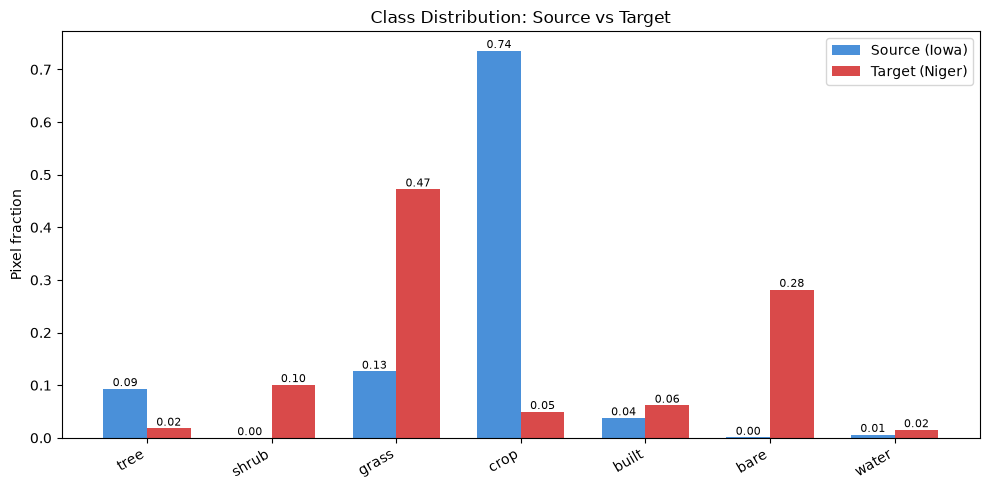

\nSource class frequencies: {'tree': '0.093', 'shrub': '0.000', 'grass': '0.126', 'crop': '0.736', 'built': '0.038', 'bare': '0.001', 'water': '0.006'}
Target class frequencies: {'tree': '0.018', 'shrub': '0.101', 'grass': '0.473', 'crop': '0.050', 'built': '0.062', 'bare': '0.282', 'water': '0.015'}


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
width = 0.35

ax.bar(x - width / 2, src_stats["class_freq"], width, label="Source (Iowa)", color="#4A90D9")
ax.bar(x + width / 2, tgt_stats["class_freq"], width, label="Target (Niger)", color="#D94A4A")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("Pixel fraction")
ax.set_title("Class Distribution: Source vs Target")
ax.legend()

for i in range(NUM_CLASSES):
    ax.annotate(f'{src_stats["class_freq"][i]:.2f}', (x[i] - width/2, src_stats["class_freq"][i]),
                ha="center", va="bottom", fontsize=8)
    ax.annotate(f'{tgt_stats["class_freq"][i]:.2f}', (x[i] + width/2, tgt_stats["class_freq"][i]),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../report/figures/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\\nSource class frequencies:", {n: f"{f:.3f}" for n, f in zip(CLASS_NAMES, src_stats["class_freq"])})
print("Target class frequencies:", {n: f"{f:.3f}" for n, f in zip(CLASS_NAMES, tgt_stats["class_freq"])})